In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
data = pd.read_csv('/content/soil moisture dataset.zip')  # replace with your file name

print(data.head())
print(data.info())

                        Time   Humidity  Atmospheric_Temp  Soil_Temp  \
0  2017-06-11 21:00:21+00:00  25.252367         15.487149  12.457884   
1  2017-06-11 22:00:21+00:00  33.304246         12.115891   8.514263   
2  2017-06-11 23:00:21+00:00  24.072051         17.319203  11.913326   
3  2017-06-12 00:00:21+00:00  45.026218         15.865805  14.700958   
4  2017-06-12 01:00:21+00:00  41.490917         13.842739   8.495549   

   Soil_Moisture  Dew_Point  
0      63.077305  23.918315  
1      40.097357  31.542544  
2     100.141916  21.142841  
3      64.638742  42.217799  
4      97.964697  38.257137  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8761 entries, 0 to 8760
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Time              8761 non-null   object 
 1   Humidity          8761 non-null   float64
 2   Atmospheric_Temp  8761 non-null   float64
 3   Soil_Temp         8761 non-null   float64

In [ ]:
X = data[['Humidity','Atmospheric_Temp','Soil_Temp','Dew_Point']]

def classify_moisture(x):
    if x < 40:
        return 0   # Low
    elif x < 70:
        return 1   # Medium
    else:
        return 2   # High

data['Soil_Class'] = data['Soil_Moisture'].apply(classify_moisture)

y = data['Soil_Class']   # classification target

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Use the SMOTE-resampled data for train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res # Added stratify for balanced split
)

In [ ]:
print(f"Shape of X_res (input to train_test_split): {X_res.shape}")
print(f"Shape of y_res (input to train_test_split): {y_res.shape}")

Shape of X_res (input to train_test_split): (15711, 1, 4)
Shape of y_res (input to train_test_split): (15711, 3)


In [ ]:
print(data['Soil_Class'].unique())
print(data['Soil_Class'].value_counts())

[1 2 0]
Soil_Class
2    5237
1    2221
0    1303
Name: count, dtype: int64


In [ ]:
from tensorflow.keras.utils import to_categorical

# 'y' is already one-hot encoded from a previous step, if not, it should be done here.
# y = to_categorical(y) # This line was already executed and created y of shape (N,3) with N=37470.

model = Sequential()

# Ensure input_shape matches the current X_train shape: (timesteps, num_features)
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(32))
model.add(Dropout(0.3))

# Output layer should match the number of classes in y_train (e.g., 3 for Soil_Class 0, 1, 2)
model.add(Dense(y_train.shape[1], activation='softmax'))  # MULTI-CLASS

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np
from tensorflow.keras.utils import to_categorical # Import to_categorical

sm = SMOTE(random_state=42) # Add random_state for reproducibility

# y is currently integer labels from G5O57d-AM2ZC
y_int = y # Use y directly as integer labels

# X_scaled is currently (num_samples, num_features) from wt59k9tqM9Tw
# Apply SMOTE to the 2D data and integer labels
X_res_2d, y_res_int = sm.fit_resample(X_scaled, y_int)

# Reshape X_res_2d back to the LSTM input format: (num_samples_resampled, 1, num_features)
# The model's input_shape=(1, num_features) implies a time_steps of 1.
X_res = X_res_2d.reshape(X_res_2d.shape[0], 1, X_res_2d.shape[1])

# Convert y_res_int back to one-hot encoding for model training
num_classes = len(np.unique(y_int))
y_res = to_categorical(y_res_int, num_classes=num_classes)

NameError: name 'y' is not defined

In [ ]:
X_scaled = X_scaled.reshape((X_scaled.shape[0] * X_scaled.shape[1], 1, X_scaled.shape[2]))

# IMPORTANT: This reshape significantly increases the number of samples.
# You will need to adjust the 'y' target variable accordingly,
# typically by repeating each original 'y' value for each time step.
# For example, if y was (N, C) and X_scaled became (N*T, 1, F),
# you would need to repeat y: y = np.repeat(y, time_steps, axis=0)
# After adjusting y, ensure you re-run train_test_split.

In [ ]:
model = Sequential()

model.add(LSTM(256, return_sequences=True, input_shape=(time_steps, X.shape[1])))
model.add(Dropout(0.3))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dense(len(np.unique(y)), activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_31 (LSTM)                  │ (None, 3, 256)         │       267,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_32 (LSTM)                  │ (None, 3, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 3, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_33 (LSTM)                  │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 518,082 (1.98 MB)

 Trainable params: 518,082 (1.98 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(1, X_scaled.shape[2])))
model.add(Dropout(0.3))

model.add(LSTM(64))
model.add(Dropout(0.3))

model.add(Dense(y.shape[1], activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3316 - loss: 1.0990 - val_accuracy: 0.3321 - val_loss: 1.0987
Epoch 2/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3361 - loss: 1.0987 - val_accuracy: 0.3334 - val_loss: 1.0987
Epoch 3/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3379 - loss: 1.0988 - val_accuracy: 0.3321 - val_loss: 1.0989
Epoch 4/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3354 - loss: 1.0988 - val_accuracy: 0.3341 - val_loss: 1.0987
Epoch 5/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.3334 - loss: 1.0988 - val_accuracy: 0.3341 - val_loss: 1.0988
Epoch 6/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3305 - loss: 1.0988 - val_accuracy: 0.3327 - val_loss: 1.0986
Epoch 7/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.3337 - loss: 1.0987 - val_accuracy: 0.3341 - val_loss: 1.0986
Epoch 8/100
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.3317 - loss:

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", accuracy * 100)

Test Accuracy: 37.32103109359741


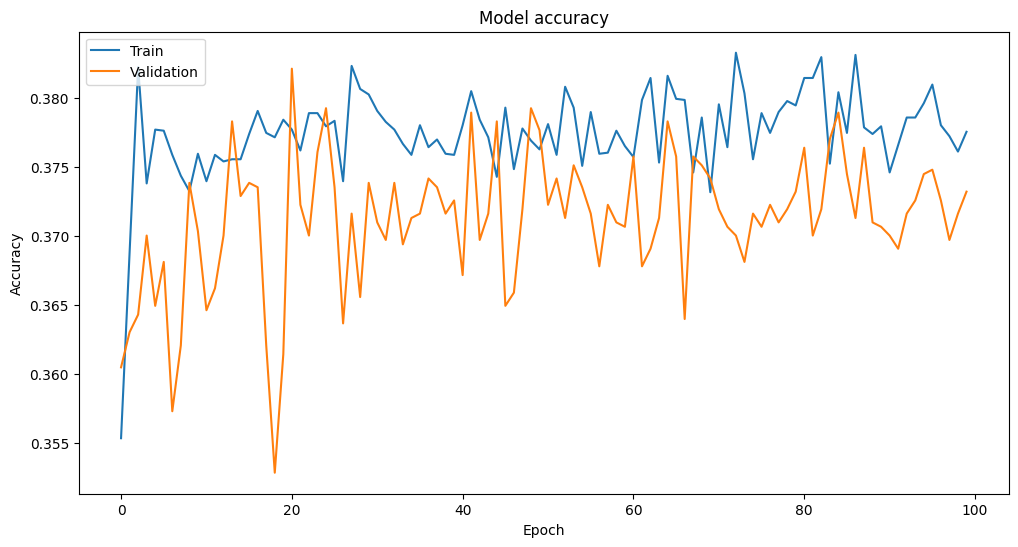

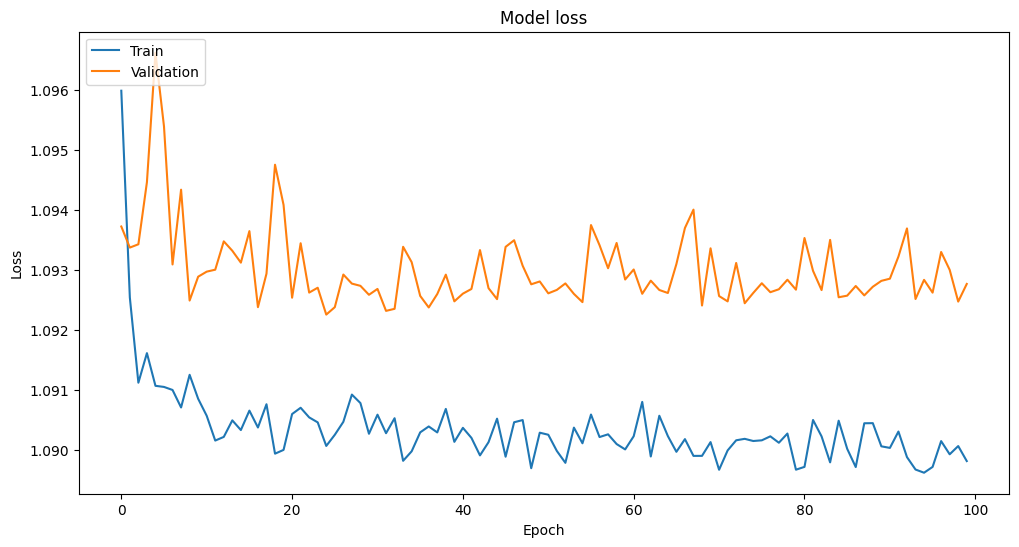

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.5130 - loss: 0.6934 - val_accuracy: 0.5029 - val_loss: 0.6928
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5128 - loss: 0.6933 - val_accuracy: 0.5021 - val_loss: 0.6933
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5209 - loss: 0.6921 - val_accuracy: 0.5043 - val_loss: 0.6931
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5246 - loss: 0.6918 - val_accuracy: 0.5171 - val_loss: 0.6920
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5248 - loss: 0.6913 - val_accuracy: 0.5321 - val_loss: 0.6912
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5180 - loss: 0.6910 - val_accuracy: 0.5414 - val_loss: 0.6911
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5248 - loss: 0.6906 - val_accuracy: 0.5321 - val_loss: 0.6914
Epoch 8/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5285 - loss: 0.6906 - val_accu

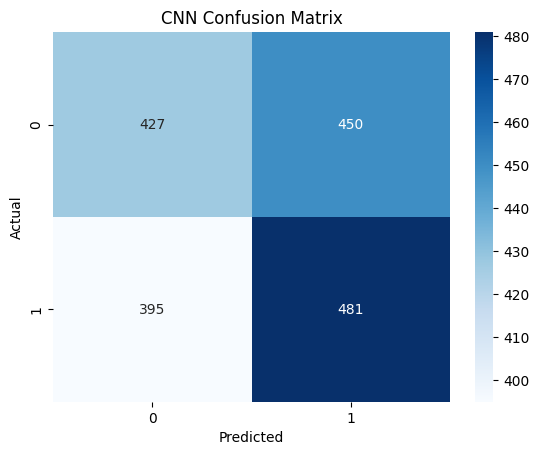

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


351/351 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4882 - loss: 0.6938 - val_accuracy: 0.5100 - val_loss: 0.6929
Epoch 2/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5071 - loss: 0.6928 - val_accuracy: 0.4979 - val_loss: 0.6948
Epoch 3/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5121 - loss: 0.6928 - val_accuracy: 0.5021 - val_loss: 0.6932
Epoch 4/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5144 - loss: 0.6929 - val_accuracy: 0.5050 - val_loss: 0.6921
Epoch 5/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5157 - loss: 0.6924 - val_accuracy: 0.5250 - val_loss: 0.6916
Epoch 6/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5248 - loss: 0.6920 - val_accuracy: 0.5150 - val_loss: 0.6914
Epoch 7/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5210 - loss: 0.6914 - val_accuracy: 0.5235 - val_loss: 0.6922
Epoch 8/100
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5203 - loss: 0.6913 - val_accuracy: 0.5200

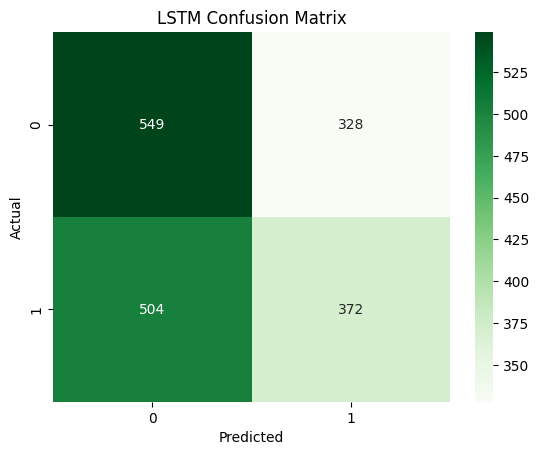

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

FILE_NAME = "/content/soil moisture dataset.zip"

df = pd.read_csv(FILE_NAME)

df = df.dropna()

FEATURE_NAMES = ['Humidity', 'Atmospheric_Temp', 'Soil_Temp', 'Dew_Point']

X = df[FEATURE_NAMES].values
y = (df['Soil_Moisture'] > df['Soil_Moisture'].median()).astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

cnn_model = Sequential([
    Conv1D(64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1],1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_pred_cnn = (cnn_model.predict(X_test) > 0.5).astype(int).flatten()

print("\n===== CNN RESULTS =====")
print(classification_report(y_test, y_pred_cnn))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

lstm_model = Sequential([
    LSTM(64, activation='tanh', return_sequences=False, input_shape=(X_train.shape[1],1)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

y_pred_lstm = (lstm_model.predict(X_test) > 0.5).astype(int).flatten()

print("\n===== LSTM RESULTS =====")
print(classification_report(y_test, y_pred_lstm))

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()